# Monte Carlo Option Pricer — Fase 2: validazione con Black-Scholes

Nella Fase 1 il Monte Carlo ha prodotto una **stima** con il suo errore standard. Ma una stima *precisa* non è per forza *giusta*: un bug nel modello o nel payoff darebbe un numero sbagliato con un errore standard piccolissimo. Serve un riferimento esterno.

Per call e put europee sotto GBM esiste la soluzione esatta, la formula di **Black-Scholes**:

$$C = S_0\,N(d_1) - K e^{-rT} N(d_2) \qquad\qquad P = K e^{-rT} N(-d_2) - S_0\,N(-d_1)$$

$$d_2 = \frac{\ln(S_0/K) + \left(r - \tfrac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}}, \qquad d_1 = d_2 + \sigma\sqrt{T}$$

dove $N(\cdot)$ è la funzione di ripartizione della normale standard. Il numeratore di $d_2$ usa lo stesso drift $r - \tfrac{1}{2}\sigma^2$ della simulazione: $d_2$ misura, in deviazioni standard, quanto il log-prezzo atteso a scadenza sta sopra $\ln K$. Per questo $N(d_2)$ è la probabilità risk-neutral che la call finisca in the money.

**Il test.** Se il motore Monte Carlo è corretto, il prezzo Black-Scholes deve cadere nel suo intervallo di confidenza (circa 95 volte su 100) e lo scarto deve ridursi come $1/\sqrt{N}$. Superato il test dove la risposta è nota, possiamo fidarci del motore anche sui contratti che una formula chiusa non ce l'hanno.

**Architettura.** Due moduli nuovi; i moduli della Fase 1 restano invariati.

| Modulo | Responsabilità | Contenuto |
|---|---|---|
| `models.py` | *come* si muove il sottostante | `GBM` |
| `instruments.py` | *cosa* paga il contratto | `EuropeanCall`, `EuropeanPut` |
| `monte_carlo.py` | prezzo **stimato** (numerico) | `price_monte_carlo`, `MCResult` |
| `black_scholes.py` *(nuovo)* | prezzo **esatto** (formula chiusa) | `price_black_scholes`, `d1_d2` |
| `validation.py` *(nuovo)* | confronto tra i due motori | `compare_with_black_scholes`, `convergence_study` |

## 0. Setup

In [1]:
# Rende importabile il package option_pricer, sia su Colab sia in locale
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/FedeDiCandia/monte-carlo-option-pricer.git"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Su Colab il progetto non c'è: lo scarica da GitHub, una volta per sessione
    PROJECT_DIR = Path("/content/monte-carlo-option-pricer")
    if not PROJECT_DIR.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(PROJECT_DIR)], check=True)
else:
    # In locale il notebook sta in notebooks/, il package nella cartella superiore
    PROJECT_DIR = Path.cwd().parent

# Controllo esplicito: senza, un percorso sbagliato farebbe fallire gli import della cella dopo con un errore poco chiaro
if not (PROJECT_DIR / "option_pricer" / "plotting.py").is_file():
    raise FileNotFoundError(
        f"Package option_pricer non trovato in {PROJECT_DIR}. "
        "Su Colab: Runtime → Disconnetti ed elimina runtime, poi esegui di nuovo tutto. "
        "In locale: apri il notebook dalla cartella notebooks/ del progetto."
    )

sys.path.insert(0, str(PROJECT_DIR))
print("Package option_pricer pronto.")

Package option_pricer pronto.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from option_pricer import (
    GBM, EuropeanCall, EuropeanPut,
    compare_with_black_scholes, convergence_study, d1_d2, price_black_scholes,
)
from option_pricer.plotting import BLACK, FILL, add_caption, apply_style

# Stile grafico accademico comune a tutti i notebook: font serif, riquadro con tacche interne, scala di grigi
apply_style()

## 1. Parametri

Gli stessi della Fase 1, così i risultati sono confrontabili.

In [3]:
# --- Mercato (modello) ---
S0 = 100.0      # prezzo spot del sottostante oggi
r = 0.05        # tasso risk-free annuo, capitalizzazione continua
sigma = 0.20    # volatilità annua

# --- Contratto (strumento) ---
K = 100.0       # strike: K = S0, opzione "at-the-money"
T = 1.0         # scadenza in anni

# --- Numerici (motore) ---
N = 200_000     # numero di traiettorie simulate
SEED = 42       # seme casuale: stessi numeri a ogni esecuzione

model = GBM(S0=S0, r=r, sigma=sigma)
call = EuropeanCall(K=K, T=T)
put = EuropeanPut(K=K, T=T)

## 2. Prezzo esatto di Black-Scholes

Prima di usare la formula come riferimento, due controlli che non dipendono dal Monte Carlo:

1. **Put-call parity**: $C - P = S_0 - K e^{-rT}$. Vale per *qualsiasi* modello senza arbitraggio (una call lunga più una put corta replica un forward), quindi verifica che le formule di call e put siano coerenti tra loro: un segno sbagliato nella put la violerebbe.
2. **$N(d_2)$ = probabilità di esercizio**: deve coincidere con la frequenza di $S_T > K$ nelle traiettorie simulate.

In [4]:
bs_call = price_black_scholes(model, call)
bs_put = price_black_scholes(model, put)
print(f"Black-Scholes:  call = {bs_call:.4f}   put = {bs_put:.4f}")

# Controllo 1 — put-call parity: lo scarto deve essere zero, a meno dell'arrotondamento in virgola mobile
parity_gap = (bs_call - bs_put) - (S0 - K * np.exp(-r * T))
print(f"Put-call parity:  (C - P) - (S0 - K·e^(-rT)) = {parity_gap:.1e}")

# Controllo 2 — N(d2) contro la frequenza simulata di esercizio della call
d1, d2 = d1_d2(S0, K, T, r, sigma)
S_T = model.simulate_paths(T=T, n_steps=1, n_paths=N, rng=np.random.default_rng(SEED))[:, -1]
print(f"P(S_T > K):  N(d2) = {norm.cdf(d2):.2%}   frequenza simulata = {np.mean(S_T > K):.2%}")

Black-Scholes:  call = 10.4506   put = 5.5735
Put-call parity:  (C - P) - (S0 - K·e^(-rT)) = 0.0e+00
P(S_T > K):  N(d2) = 55.96%   frequenza simulata = 55.84%


## 3. Confronto diretto: Monte Carlo vs Black-Scholes

Stessi parametri, stessi oggetti `model` e `instrument` passati ai due motori. Lo scarto va letto in **errori standard** (z-score):

$$z = \frac{\text{prezzo MC} - \text{prezzo BS}}{\text{SE}}$$

Se il motore è corretto, per il Teorema del Limite Centrale $z$ si comporta come una $\mathcal{N}(0,1)$: $|z| < 1.96$ nel 95% dei casi. Un singolo $|z|$ appena sopra 2 capita una volta su venti e non è un bug; un $|z|$ di 5 o 10 invece lo è quasi certamente.

In [5]:
for name, instrument in [("Call", call), ("Put ", put)]:
    print(f"{name}:  {compare_with_black_scholes(model, instrument, n_paths=N, seed=SEED)}")

Call:  MC 10.4634 ± 0.0331  |  BS 10.4506  |  scarto +0.0128 = +0.39 SE  |  BS dentro l'IC 95%
Put :  MC 5.5889 ± 0.0194  |  BS 5.5735  |  scarto +0.0154 = +0.79 SE  |  BS dentro l'IC 95%


## 4. Stesso test su più scenari

Un solo test at-the-money è debole: con $S_0 = K$ certi bug restano invisibili. Ad esempio, scambiare $S_0$ e $K$ nella formula della call dà lo stesso numero quando i due coincidono. Ripetiamo il confronto con opzioni in e out of the money, volatilità alta, scadenze brevi e lunghe.

In [6]:
scenarios = [
    # descrizione                S0      K     T     r     sigma
    ("ATM (caso base)",        100.0, 100.0, 1.0, 0.05, 0.20),
    ("Call ITM / put OTM",     100.0,  80.0, 1.0, 0.05, 0.20),
    ("Call OTM / put ITM",     100.0, 120.0, 1.0, 0.05, 0.20),
    ("Volatilità alta",        100.0, 100.0, 1.0, 0.05, 0.50),
    ("Scadenza breve (1 mese)", 100.0, 100.0, 1/12, 0.05, 0.20),
    ("Scadenza lunga (5 anni)", 100.0, 100.0, 5.0, 0.05, 0.20),
]

z_scores = []
print(f"{'Scenario':<25}{'Tipo':<6}{'BS':>9}{'MC':>9}{'SE':>8}{'z':>7}   IC 95%")
for i, (label, s0, k, t, rate, vol) in enumerate(scenarios):
    scenario_model = GBM(S0=s0, r=rate, sigma=vol)
    for kind, Option in [("call", EuropeanCall), ("put", EuropeanPut)]:
        # Seme diverso per scenario; dentro lo stesso scenario call e put condividono le traiettorie
        res = compare_with_black_scholes(scenario_model, Option(K=k, T=t), n_paths=N, seed=SEED + i)
        z_scores.append(res.z_score)
        print(f"{label:<25}{kind:<6}{res.bs_price:>9.4f}{res.mc.price:>9.4f}{res.mc.std_error:>8.4f}"
              f"{res.z_score:>+7.2f}   {'dentro' if res.within_ci else 'FUORI'}")

print(f"\nz-score massimo in valore assoluto: {np.max(np.abs(z_scores)):.2f}")

Scenario                 Tipo         BS       MC      SE      z   IC 95%
ATM (caso base)          call    10.4506  10.4634  0.0331  +0.39   dentro
ATM (caso base)          put      5.5735   5.5889  0.0194  +0.79   dentro
Call ITM / put OTM       call    24.5888  24.4949  0.0427  -2.20   FUORI
Call ITM / put OTM       put      0.6872   0.6843  0.0060  -0.48   dentro
Call OTM / put ITM       call     3.2475   3.2737  0.0195  +1.34   dentro
Call OTM / put ITM       put     17.3950  17.3947  0.0331  -0.01   dentro
Volatilità alta          call    21.7926  21.8105  0.0921  +0.19   dentro
Volatilità alta          put     16.9155  16.9155  0.0451  -0.00   dentro
Scadenza breve (1 mese)  call     2.5121   2.5046  0.0081  -0.92   dentro
Scadenza breve (1 mese)  put      2.0963   2.1019  0.0070  +0.81   dentro
Scadenza lunga (5 anni)  call    29.1386  29.1751  0.0912  +0.40   dentro
Scadenza lunga (5 anni)  put      7.0187   7.0477  0.0268  +1.08   dentro

z-score massimo in valore assoluto: 2.

### Un "FUORI" in tabella è un bug?

Con `SEED = 42` la call ITM finisce fuori dall'intervallo ($z \approx -2{,}2$). Non è un allarme: con 12 test al 95%, anche con un motore perfetto almeno uno sfora quasi una volta su due ($1 - 0{,}95^{12} \approx 46\%$, se i test fossero indipendenti). Cambiare seme finché tutto risulta "dentro" sarebbe barare.

La verifica corretta è ripetere **quello** scenario molte volte con semi diversi. Se il motore è corretto gli z-score seguono una $\mathcal{N}(0,1)$: media vicina a 0 (con 500 ripetizioni l'incertezza sulla media è $1/\sqrt{500} \approx 0{,}045$), deviazione standard vicina a 1, circa il 95% dentro $\pm 1{,}96$. Un bug sistematico sposterebbe la media lontano da zero.

In [7]:
# Lo scenario "sospetto": call in the money (K = 80), ripetuta 500 volte con semi diversi
itm_model = GBM(S0=100.0, r=0.05, sigma=0.20)
itm_call = EuropeanCall(K=80.0, T=1.0)

# N più piccolo (20.000) per velocità: lo z-score è già normalizzato per l'errore standard, quindi resta confrontabile
z_rep = np.array([
    compare_with_black_scholes(itm_model, itm_call, n_paths=20_000, seed=1_000 + j).z_score
    for j in range(500)
])

print(f"Media degli z-score:     {z_rep.mean():+.3f}   (atteso 0 ± 0.045)")
print(f"Dev. std degli z-score:  {z_rep.std(ddof=1):.3f}    (attesa 1)")
print(f"Quota con |z| < 1.96:    {np.mean(np.abs(z_rep) < 1.96):.1%}   (attesa 95%)")

Media degli z-score:     -0.021   (atteso 0 ± 0.045)
Dev. std degli z-score:  1.027    (attesa 1)
Quota con |z| < 1.96:    94.8%   (attesa 95%)


## 5. Convergenza verso Black-Scholes

Per ogni $N$ su una griglia logaritmica da 100 a 1.000.000 rifacciamo il pricing con una simulazione **indipendente** (seme diverso). Ogni punto è una stima Monte Carlo, la linea nera è il prezzo esatto.

La banda grigia è dove le stime *dovrebbero* cadere se il motore è corretto: prezzo esatto $\pm 1{,}96\, s/\sqrt{N}$, con $s$ deviazione standard dei payoff scontati. Si stringe come $1/\sqrt{N}$: passando da 100 a 1.000.000 traiettorie ($\times 10^4$) diventa 100 volte più stretta. Circa il 95% dei punti deve cadere al suo interno.

Call: 23 stime su 25 dentro la banda attesa al 95%
Put: 24 stime su 25 dentro la banda attesa al 95%


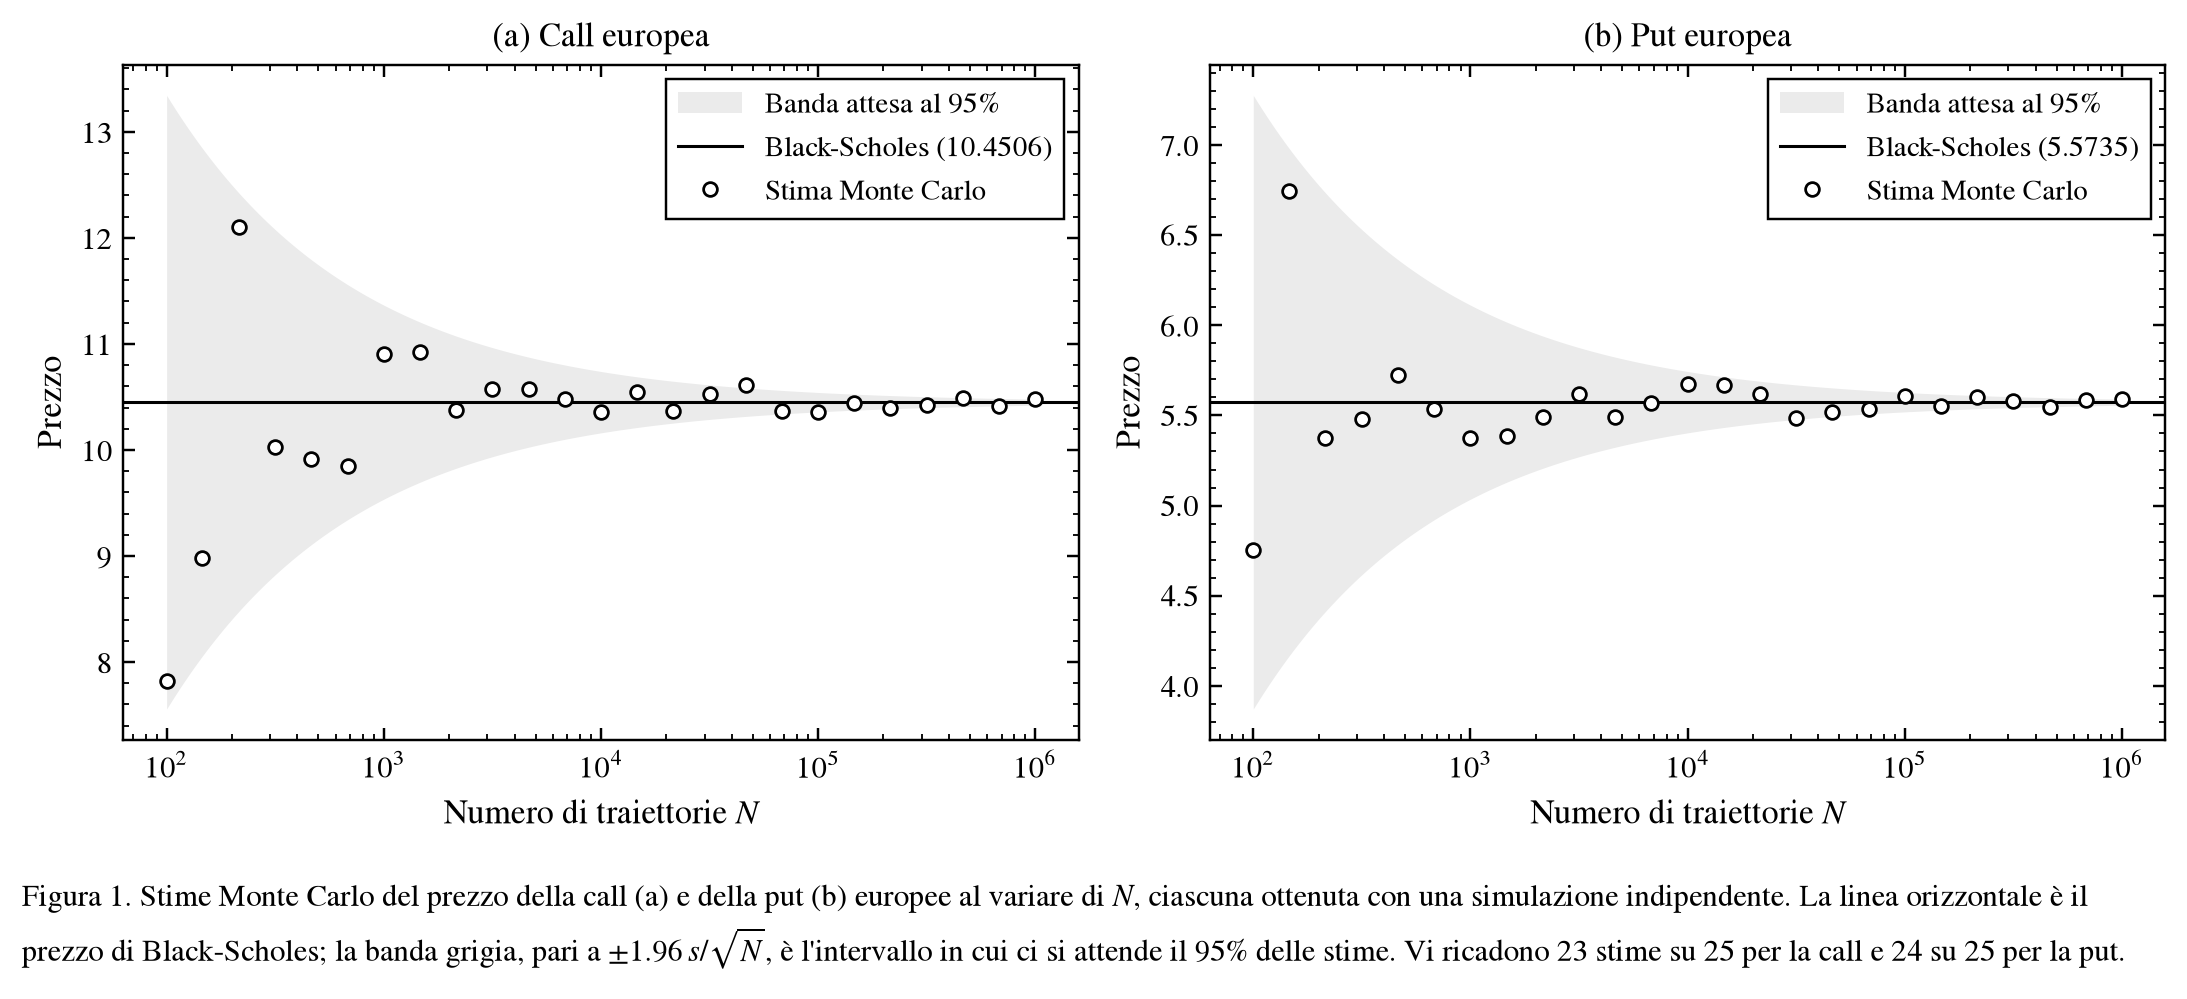

In [8]:
# 25 valori di N equispaziati in scala logaritmica, da 10^2 a 10^6
n_values = np.unique(np.geomspace(100, 1_000_000, 25).astype(int))
z = norm.ppf(0.975)  # ≈ 1.96

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
inside_counts = []
for ax, panel, (name, instrument) in zip(axes, "ab", [("Call", call), ("Put", put)]):
    results = convergence_study(model, instrument, n_values, seed=SEED)
    prices = np.array([res.price for res in results])
    bs_price = price_black_scholes(model, instrument)

    # Banda attesa: prezzo esatto ± 1.96 · s/√N. La dev. std s dei payoff scontati si ricava
    # dalla stima con più traiettorie, invertendo SE = s/√N
    s_payoff = results[-1].std_error * np.sqrt(n_values[-1])
    n_grid = np.geomspace(n_values[0], n_values[-1], 200)
    band = z * s_payoff / np.sqrt(n_grid)
    inside = np.abs(prices - bs_price) <= z * s_payoff / np.sqrt(n_values)
    inside_counts.append(int(inside.sum()))

    ax.fill_between(n_grid, bs_price - band, bs_price + band, color=FILL, linewidth=0, label="Banda attesa al 95%")
    ax.axhline(bs_price, color=BLACK, linewidth=1.0, label=f"Black-Scholes ({bs_price:.4f})")
    ax.plot(n_values, prices, "o", color=BLACK, markerfacecolor="white", markeredgewidth=0.9, markersize=4.5,
            label="Stima Monte Carlo")
    ax.set_xscale("log")
    ax.set_title(f"({panel}) {name} europea")
    ax.set(xlabel=r"Numero di traiettorie $N$", ylabel="Prezzo")
    ax.legend(loc="upper right")
    print(f"{name}: {inside.sum()} stime su {len(results)} dentro la banda attesa al 95%")

fig.tight_layout()
add_caption(fig, 1,
    rf"Stime Monte Carlo del prezzo della call (a) e della put (b) europee al variare di $N$, ciascuna ottenuta con "
    rf"una simulazione indipendente. La linea orizzontale è il prezzo di Black-Scholes; la banda grigia, pari a "
    rf"$\pm1.96\,s/\sqrt{{N}}$, è l'intervallo in cui ci si attende il 95% delle stime. Vi ricadono "
    rf"{inside_counts[0]} stime su {len(n_values)} per la call e {inside_counts[1]} su {len(n_values)} per la put.")
plt.show()

## Riepilogo

- **Formula di Black-Scholes verificata da sola**, senza Monte Carlo: la put-call parity è rispettata a meno dell'arrotondamento e $N(d_2) = 55{,}96\%$ coincide con la frequenza di esercizio simulata ($55{,}84\%$).
- **Confronto diretto** (stessi parametri della Fase 1): call $10{,}4634$ contro $10{,}4506$ ($z = +0{,}39$), put $5{,}5889$ contro $5{,}5735$ ($z = +0{,}79$). Il prezzo esatto cade dentro l'intervallo di confidenza in entrambi i casi.
- **Più scenari** (ITM, OTM, volatilità alta, scadenze da 1 mese a 5 anni): $|z|$ massimo $\approx 2{,}2$. L'unico caso fuori dall'intervallo è compatibile con il caso: ripetuto 500 volte, lo z-score ha media $\approx 0$ e deviazione standard $\approx 1$, quindi nessuna distorsione.
- **Convergenza**: la banda in cui ci aspettiamo le stime si stringe come $1/\sqrt{N}$, e i punti la seguono fino alla linea di Black-Scholes.

**Conclusione:** dove conosciamo la risposta esatta, il motore Monte Carlo la ritrova entro il suo errore statistico. Abbiamo quindi una base affidabile per usarlo dove una formula chiusa non esiste.